# 딥러닝 오버피팅 방지 기법 실습 - TensorFlow/Keras 버전


> 이 노트북은 오버피팅을 직접 확인하고, 방지 기법을 적용한 모델과 비교하는 실습입니다.  

## 실습 목표

1. Fashion-MNIST 데이터로 오버피팅을 확인합니다.
2. 복잡한 모델과 정규화 모델을 비교합니다.
3. TensorFlow/Keras에서 다음 기법을 적용합니다.
   - 데이터 증강
   - Dropout
   - Batch Normalization
   - L2 Regularization
   - Early Stopping
   - Label Smoothing
   - 모델 단순화

In [1]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

# TensorFlow는 딥러닝 모델 생성과 학습을 위한 대표 라이브러리입니다.
import tensorflow as tf

# keras는 TensorFlow 안에서 고수준 딥러닝 API를 제공합니다.
from tensorflow import keras

# layers는 Dense, Dropout, BatchNormalization 같은 신경망 계층을 제공합니다.
from tensorflow.keras import layers

# regularizers는 L2 정규화 같은 가중치 규제 기능을 제공합니다.
from tensorflow.keras import regularizers

# numpy는 배열 처리와 수치 계산에 사용합니다.
import numpy as np

# matplotlib은 학습 결과 그래프를 그리기 위해 사용합니다.
import matplotlib.pyplot as plt

# random은 파이썬 난수 생성을 제어하기 위해 사용합니다.
import random

# ============================================================
# 2. 실험 결과를 최대한 일정하게 만들기 위한 시드 고정
# ============================================================

# 난수 시드를 42로 고정합니다.
SEED = 42

# 파이썬 random 모듈의 시드를 고정합니다.
random.seed(SEED)

# numpy 난수 시드를 고정합니다.
np.random.seed(SEED)

# TensorFlow 난수 시드를 고정합니다.
tf.random.set_seed(SEED)

# TensorFlow 버전을 출력합니다.
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 1단계: Fashion-MNIST 데이터 준비

Keras에서 제공하는 Fashion-MNIST 데이터를 사용합니다.  
오버피팅을 보기 쉽게 하기 위해 학습 데이터 일부만 사용합니다.

In [2]:
# ============================================================
# 3. Fashion-MNIST 데이터셋 불러오기
# ============================================================

# Keras 내장 Fashion-MNIST 데이터셋을 불러옵니다.
# 반환값은 학습 데이터와 테스트 데이터입니다.
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# ============================================================
# 4. 데이터 정규화 및 차원 변환
# ============================================================

# 이미지 픽셀값은 원래 0~255 범위입니다.
# 255.0으로 나누어 0~1 범위로 변환합니다.
x_train_full = x_train_full.astype('float32') / 255.0

# 테스트 이미지도 같은 방식으로 0~1 범위로 변환합니다.
x_test = x_test.astype('float32') / 255.0

# CNN/증강 계층과 호환되도록 채널 차원을 추가합니다.
# 기존 shape: (개수, 28, 28)
# 변경 shape: (개수, 28, 28, 1)
x_train_full = np.expand_dims(x_train_full, axis=-1)

# 테스트 데이터에도 채널 차원을 추가합니다.
x_test = np.expand_dims(x_test, axis=-1)

# ============================================================
# 5. 일부 데이터만 사용하여 오버피팅 상황 만들기
# ============================================================

# 전체 학습 데이터 중 3,000개만 선택합니다.
x_small = x_train_full[:3000]

# 선택된 3,000개 이미지에 해당하는 라벨을 선택합니다.
y_small = y_train_full[:3000]

# 앞의 2,400개는 학습용으로 사용합니다.
x_train = x_small[:2400]

# 앞의 2,400개 라벨을 학습용으로 사용합니다.
y_train = y_small[:2400]

# 나머지 600개는 검증용으로 사용합니다.
x_val = x_small[2400:]

# 나머지 600개 라벨을 검증용으로 사용합니다.
y_val = y_small[2400:]

# 학습 데이터 크기를 출력합니다.
print('학습 데이터 shape:', x_train.shape)

# 검증 데이터 크기를 출력합니다.
print('검증 데이터 shape:', x_val.shape)

# 테스트 데이터 크기를 출력합니다.
print('테스트 데이터 shape:', x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
학습 데이터 shape: (2400, 28, 28, 1)
검증 데이터 shape: (600, 28, 28, 1)
테스트 데이터 shape: (10000, 28, 28, 1)


## 2단계: 데이터 증강 계층 정의

Keras에서는 모델 앞부분에 데이터 증강 계층을 넣을 수 있습니다.  
학습 중에만 무작위 변형이 적용되고, 검증/테스트 단계에서는 일반적으로 비활성화됩니다.

In [3]:
# ============================================================
# 6. 데이터 증강 계층 정의
# ============================================================

# Sequential은 여러 계층을 순서대로 묶는 Keras 모델 형식입니다.
data_augmentation = keras.Sequential([
    # 이미지를 좌우 방향으로 무작위 이동합니다.
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    # 이미지를 최대 약 10% 정도 무작위 회전합니다.
    layers.RandomRotation(factor=0.1),

    # 이미지를 약간 확대 또는 축소합니다.
    layers.RandomZoom(height_factor=0.1, width_factor=0.1)
], name='data_augmentation')

## 3단계: 오버피팅 모델과 방지 기법 적용 모델 정의

기준 모델은 일부러 크게 만들어 오버피팅을 확인합니다.  
정규화 모델은 데이터 증강, Dropout, Batch Normalization, L2 Regularization 등을 포함합니다.

In [4]:
# ============================================================
# 7. 오버피팅 관찰용 복잡한 모델 생성 함수
# ============================================================

def build_overfit_model():
    # Sequential API로 순차적인 신경망을 생성합니다.
    model = keras.Sequential([
        # 입력 이미지 크기를 명시합니다.
        layers.Input(shape=(28, 28, 1)),

        # 28x28x1 이미지를 784개 숫자의 1차원 벡터로 펼칩니다.
        layers.Flatten(),

        # 1024개 뉴런을 가진 큰 은닉층입니다.
        # 작은 데이터에서는 이런 큰 계층이 오버피팅을 만들 수 있습니다.
        layers.Dense(1024, activation='relu'),

        # 512개 뉴런을 가진 두 번째 은닉층입니다.
        layers.Dense(512, activation='relu'),

        # 256개 뉴런을 가진 세 번째 은닉층입니다.
        layers.Dense(256, activation='relu'),

        # Fashion-MNIST는 10개 클래스이므로 출력 뉴런은 10개입니다.
        # softmax는 각 클래스에 대한 확률을 출력합니다.
        layers.Dense(10, activation='softmax')
    ])

    # 생성한 모델을 반환합니다.
    return model

# ============================================================
# 8. 오버피팅 방지 기법 적용 모델 생성 함수
# ============================================================

def build_regularized_model():
    # Sequential API로 정규화 모델을 생성합니다.
    model = keras.Sequential([
        # 입력 이미지 크기를 정의합니다.
        layers.Input(shape=(28, 28, 1)),

        # 학습 데이터에 무작위 변형을 적용하는 데이터 증강 계층입니다.
        data_augmentation,

        # 이미지를 1차원 벡터로 펼칩니다.
        layers.Flatten(),

        # 256개 뉴런을 사용하여 기준 모델보다 작게 구성합니다.
        # kernel_regularizer는 가중치에 L2 벌점을 추가합니다.
        layers.Dense(
            256,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.001)
        ),

        # BatchNormalization은 은닉층 출력 분포를 안정화합니다.
        layers.BatchNormalization(),

        # Dropout은 학습 중 50% 뉴런을 무작위로 비활성화합니다.
        layers.Dropout(0.5),

        # 두 번째 은닉층도 기준 모델보다 작게 구성합니다.
        layers.Dense(
            128,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.001)
        ),

        # 두 번째 배치 정규화입니다.
        layers.BatchNormalization(),

        # 두 번째 Dropout은 30% 비율로 적용합니다.
        layers.Dropout(0.3),

        # 최종 10개 클래스 확률을 출력합니다.
        layers.Dense(10, activation='softmax')
    ])

    # 생성한 모델을 반환합니다.
    return model

## 4단계: 기준 모델 학습 - 오버피팅 확인

Early Stopping이나 정규화 없이 복잡한 모델을 학습하여 오버피팅 경향을 확인합니다.

In [5]:
# ============================================================
# 9. 오버피팅 관찰용 모델 생성 및 컴파일
# ============================================================

# 복잡한 기준 모델을 생성합니다.
overfit_model = build_overfit_model()

# 모델 학습 방식을 설정합니다.
overfit_model.compile(
    # Adam은 많이 사용되는 최적화 알고리즘입니다.
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # sparse_categorical_crossentropy는 정답 라벨이 정수형일 때 사용하는 다중 분류 손실 함수입니다.
    loss='sparse_categorical_crossentropy',

    # 학습 중 정확도를 함께 확인합니다.
    metrics=['accuracy']
)

# 모델 구조를 출력합니다.
overfit_model.summary()

# ============================================================
# 10. 기준 모델 학습
# ============================================================

# 기준 모델을 30 epoch 동안 학습합니다.
# validation_data를 지정하면 매 epoch마다 검증 성능을 확인할 수 있습니다.
history_overfit = overfit_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,462,538 (5.58 MB)

 Trainable params: 1,462,538 (5.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6883 - loss: 0.9390 - val_accuracy: 0.7500 - val_loss: 0.6858
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8112 - loss: 0.5237 - val_accuracy: 0.7633 - val_loss: 0.6913
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8388 - loss: 0.4478 - val_accuracy: 0.7917 - val_loss: 0.6174
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8658 - loss: 0.3836 - val_accuracy: 0.7983 - val_loss: 0.6108
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8763 - loss: 0.3439 - val_accuracy: 0.7950 - val_loss: 0.6052
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8771 - loss: 0.3323 - val_accuracy: 0.7833 - val_loss: 0.6037
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8804 - loss: 0.3120 - val_accuracy: 0.7817 - val_loss: 0.6835
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8963 - loss: 0.3021 - val_accuracy: 0.7917 - v

## 5단계: 오버피팅 방지 기법 적용 모델 학습

이 모델에는 여러 방지 기법이 함께 적용됩니다.

- 데이터 증강: `data_augmentation`
- Dropout: `layers.Dropout`
- Batch Normalization: `layers.BatchNormalization`
- L2 Regularization: `regularizers.l2`
- Early Stopping: `keras.callbacks.EarlyStopping`
- Label Smoothing: `SparseCategoricalCrossentropy(label_smoothing=0.1)`
- 모델 단순화: 은닉층 크기 축소

In [8]:
# ============================================================
# 11. 오버피팅 방지 기법 적용 모델 생성 및 컴파일
# ============================================================

# 정규화 기법이 포함된 모델을 생성합니다.
regularized_model = build_regularized_model()

# 정규화 모델 학습 방식을 설정합니다.
regularized_model.compile(
    # AdamW는 Adam에 Weight Decay 개념을 함께 사용할 수 있는 최적화 알고리즘입니다.
    optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),

    # label_smoothing은 정답을 너무 강하게 외우는 것을 줄이기 위해 사용합니다.
    loss=keras.losses.SparseCategoricalCrossentropy(),

    # 정확도를 평가 지표로 사용합니다.
    metrics=['accuracy']
)

# 정규화 모델 구조를 출력합니다.
regularized_model.summary()

# ============================================================
# 12. Early Stopping 콜백 정의
# ============================================================

# EarlyStopping은 검증 손실이 개선되지 않으면 학습을 중단합니다.
early_stopping = keras.callbacks.EarlyStopping(
    # val_loss를 기준으로 성능 개선 여부를 판단합니다.
    monitor='val_loss',

    # 5 epoch 동안 검증 손실이 개선되지 않으면 학습을 멈춥니다.
    patience=5,

    # 가장 좋은 검증 성능을 냈던 시점의 가중치를 복원합니다.
    restore_best_weights=True
)

# ============================================================
# 13. 정규화 모델 학습
# ============================================================

# 정규화 모델을 학습합니다.
# callbacks에 EarlyStopping을 넣어 오버피팅이 심해지기 전에 멈춥니다.
history_regularized = regularized_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3812 - loss: 2.3948 - val_accuracy: 0.4933 - val_loss: 2.1124
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5321 - loss: 1.8917 - val_accuracy: 0.5483 - val_loss: 1.8956
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5300 - loss: 1.7960 - val_accuracy: 0.5950 - val_loss: 1.6491
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5667 - loss: 1.7211 - val_accuracy: 0.6417 - val_loss: 1.5002
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5929 - loss: 1.6375 - val_accuracy: 0.6850 - val_loss: 1.3927
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6042 - loss: 1.6021 - val_accuracy: 0.6967 - val_loss: 1.3454
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6000 - loss: 1.5672 - val_accuracy: 0.6850 - val_loss: 1.3200
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6087 - loss: 1.5469 - val_accuracy: 0.7017 - v

## 6단계: 학습 결과 그래프로 비교

Train Loss와 Validation Loss의 차이를 확인하여 오버피팅 여부를 판단합니다.

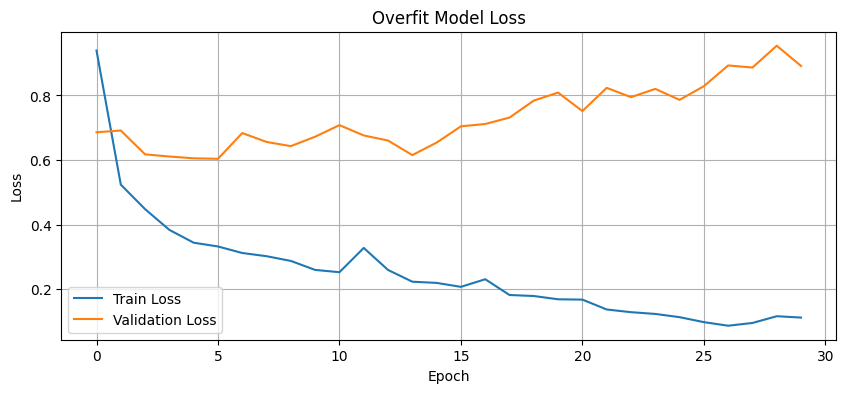

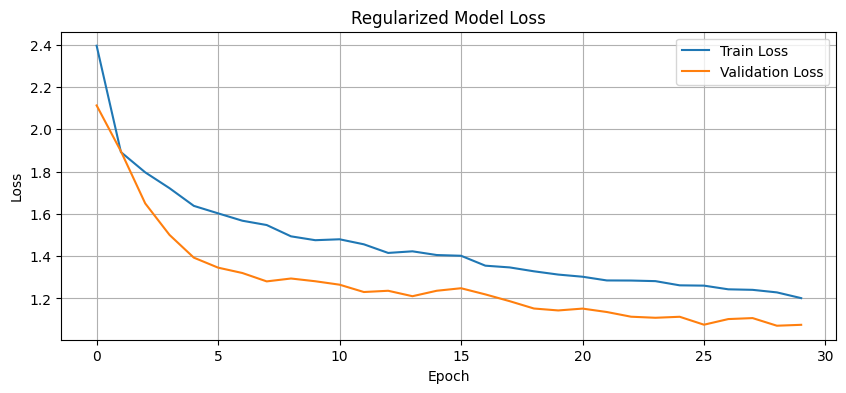

In [9]:
# ============================================================
# 14. 학습 곡선 시각화 함수 정의
# ============================================================

def plot_history(history, title):
    # Keras History 객체에서 epoch별 기록 딕셔너리를 꺼냅니다.
    hist = history.history

    # 그래프 크기를 설정합니다.
    plt.figure(figsize=(10, 4))

    # 학습 손실을 선 그래프로 표시합니다.
    plt.plot(hist['loss'], label='Train Loss')

    # 검증 손실을 선 그래프로 표시합니다.
    plt.plot(hist['val_loss'], label='Validation Loss')

    # 그래프 제목을 설정합니다.
    plt.title(title)

    # x축 이름을 설정합니다.
    plt.xlabel('Epoch')

    # y축 이름을 설정합니다.
    plt.ylabel('Loss')

    # 범례를 표시합니다.
    plt.legend()

    # 격자선을 표시합니다.
    plt.grid(True)

    # 그래프를 화면에 출력합니다.
    plt.show()

# 기준 모델의 손실 곡선을 출력합니다.
plot_history(history_overfit, 'Overfit Model Loss')

# 정규화 모델의 손실 곡선을 출력합니다.
plot_history(history_regularized, 'Regularized Model Loss')

## 7단계: 테스트 데이터로 최종 평가

테스트 데이터는 모델이 한 번도 학습하지 않은 데이터입니다.  
따라서 테스트 정확도는 모델이 새로운 데이터에 얼마나 잘 일반화하는지 확인하는 지표입니다.

In [10]:
# ============================================================
# 15. 테스트 데이터 최종 평가
# ============================================================

# 기준 모델을 테스트 데이터로 평가합니다.
test_loss_overfit, test_acc_overfit = overfit_model.evaluate(x_test, y_test, verbose=0)

# 정규화 모델을 테스트 데이터로 평가합니다.
test_loss_regularized, test_acc_regularized = regularized_model.evaluate(x_test, y_test, verbose=0)

# 기준 모델 테스트 결과를 출력합니다.
print(f'오버피팅 관찰용 모델 - Test Loss: {test_loss_overfit:.4f}, Test Acc: {test_acc_overfit:.4f}')

# 정규화 모델 테스트 결과를 출력합니다.
print(f'오버피팅 방지 적용 모델 - Test Loss: {test_loss_regularized:.4f}, Test Acc: {test_acc_regularized:.4f}')

오버피팅 관찰용 모델 - Test Loss: 0.8616, Test Acc: 0.8036
오버피팅 방지 적용 모델 - Test Loss: 1.0298, Test Acc: 0.7230


## 결과 해석 방법

- 기준 모델에서 `loss`는 낮아지지만 `val_loss`가 높아지면 오버피팅 가능성이 큽니다.
- 정규화 모델은 학습 정확도가 기준 모델보다 낮을 수 있지만 검증/테스트 성능이 더 안정적일 수 있습니다.
- 데이터가 적을수록 데이터 증강, 모델 단순화, Dropout, L2 정규화, Early Stopping을 함께 적용하는 것이 좋습니다.